In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/ai4i2020.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (10000, 14)

Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [2]:
print(df.head())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

In [3]:
print("Failure distribution:")
print(df['Machine failure'].value_counts())
print("\nFailure percentage:", round(df['Machine failure'].mean() * 100, 2), "%")

Failure distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure percentage: 3.39 %


In [4]:
print(df[['Air temperature [K]', 'Process temperature [K]', 
          'Rotational speed [rpm]', 'Torque [Nm]', 
          'Tool wear [min]']].describe().round(2))

       Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
count              10000.0                 10000.00                10000.00   
mean                 300.0                   310.01                 1538.78   
std                    2.0                     1.48                  179.28   
min                  295.3                   305.70                 1168.00   
25%                  298.3                   308.80                 1423.00   
50%                  300.1                   310.10                 1503.00   
75%                  301.5                   311.10                 1612.00   
max                  304.5                   313.80                 2886.00   

       Torque [Nm]  Tool wear [min]  
count     10000.00         10000.00  
mean         39.99           107.95  
std           9.97            63.65  
min           3.80             0.00  
25%          33.20            53.00  
50%          40.10           108.00  
75%          46.80    

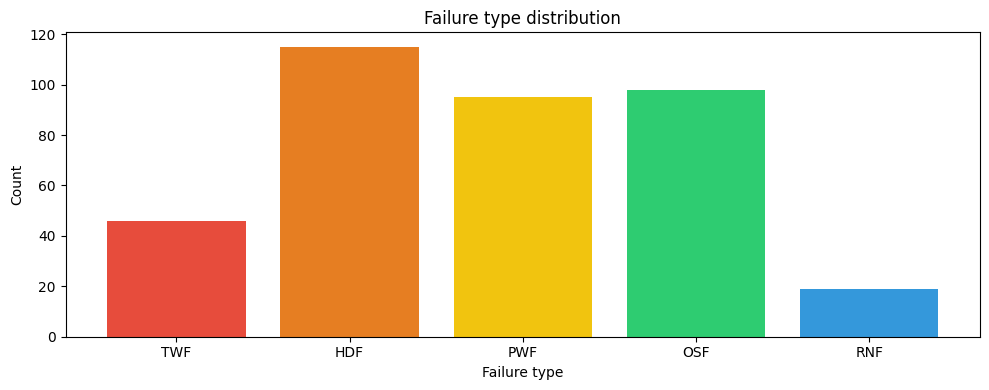

Counts: {'TWF': 46, 'HDF': 115, 'PWF': 95, 'OSF': 98, 'RNF': 19}


In [5]:
plt.figure(figsize=(10, 4))

failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
counts = [df[f].sum() for f in failure_types]

plt.bar(failure_types, counts, color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'])
plt.title('Failure type distribution')
plt.xlabel('Failure type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../data/failure_distribution.png')
plt.show()
print("Counts:", dict(zip(failure_types, counts)))

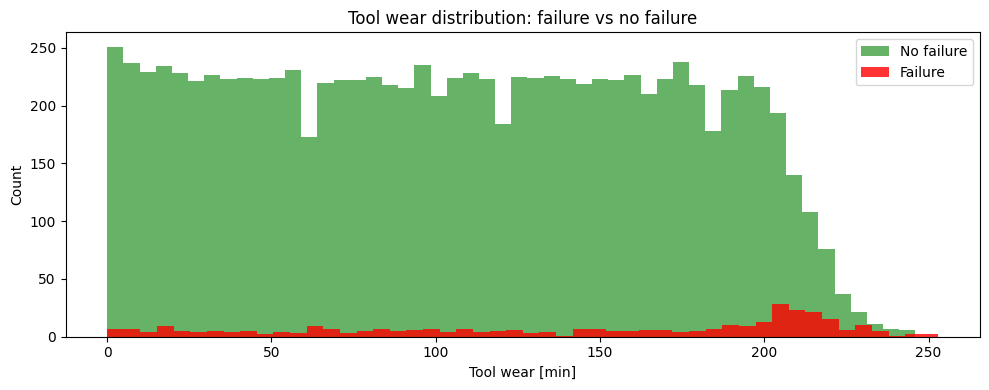

In [6]:
plt.figure(figsize=(10, 4))

plt.hist(df[df['Machine failure']==0]['Tool wear [min]'], 
         bins=50, alpha=0.6, color='green', label='No failure')
plt.hist(df[df['Machine failure']==1]['Tool wear [min]'], 
         bins=50, alpha=0.8, color='red', label='Failure')

plt.title('Tool wear distribution: failure vs no failure')
plt.xlabel('Tool wear [min]')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('../data/toolwear_vs_failure.png')
plt.show()

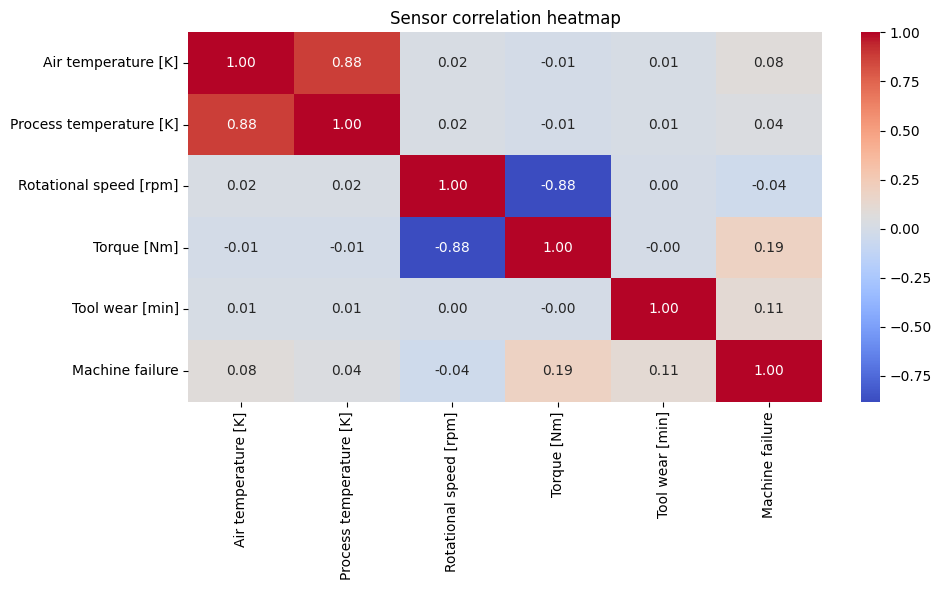

In [7]:
plt.figure(figsize=(10, 6))

features = ['Air temperature [K]', 'Process temperature [K]', 
            'Rotational speed [rpm]', 'Torque [Nm]', 
            'Tool wear [min]', 'Machine failure']

sns.heatmap(df[features].corr().round(2), 
            annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Sensor correlation heatmap')
plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png')
plt.show()